In [138]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path

In [139]:
# 01. load mtcars dataset
project_root = Path.cwd().parents[0]
fname = project_root / "datasets" / "mtcars.csv"

# verify the path
#print(fname)

df = pd.read_csv(fname)


In [140]:
# 02. Explore the Dataset
# 02-1. Review the structure of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  32 non-null     str    
 1   mpg         32 non-null     float64
 2   cyl         32 non-null     int64  
 3   disp        32 non-null     float64
 4   hp          32 non-null     int64  
 5   drat        32 non-null     float64
 6   wt          32 non-null     float64
 7   qsec        32 non-null     float64
 8   vs          32 non-null     int64  
 9   am          32 non-null     int64  
 10  gear        32 non-null     int64  
 11  carb        32 non-null     int64  
dtypes: float64(5), int64(6), str(1)
memory usage: 3.1 KB


In [141]:
# 02-2. Display the first six rows of the dataset
# displays the first 5 rows of the dataframe by default unless a number is provided as input
df.head(6)

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1


In [142]:
# 02-3. Summarize the dataset
df.describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


In [143]:
# 03. Calculate Descriptive Statistics
# Compute the mean, median, and standard deviation for the mpg variable

# using the describe method
display(df.mpg.describe())

# display mean, median, and standard deviation for the mpg variable individually
print("Display mean, median, stddev *individually*")
print(f"mpg mean: {df.mpg.mean()}")
print(f"mpg median: {df.mpg.median()}")
print(f"mpg stddev: {df.mpg.std()}")


count    32.000000
mean     20.090625
std       6.026948
min      10.400000
25%      15.425000
50%      19.200000
75%      22.800000
max      33.900000
Name: mpg, dtype: float64

Display mean, median, stddev *individually*
mpg mean: 20.090625000000003
mpg median: 19.2
mpg stddev: 6.026948052089104


Text(0.5, 1.0, 'Scatterplot mpg vs hp')

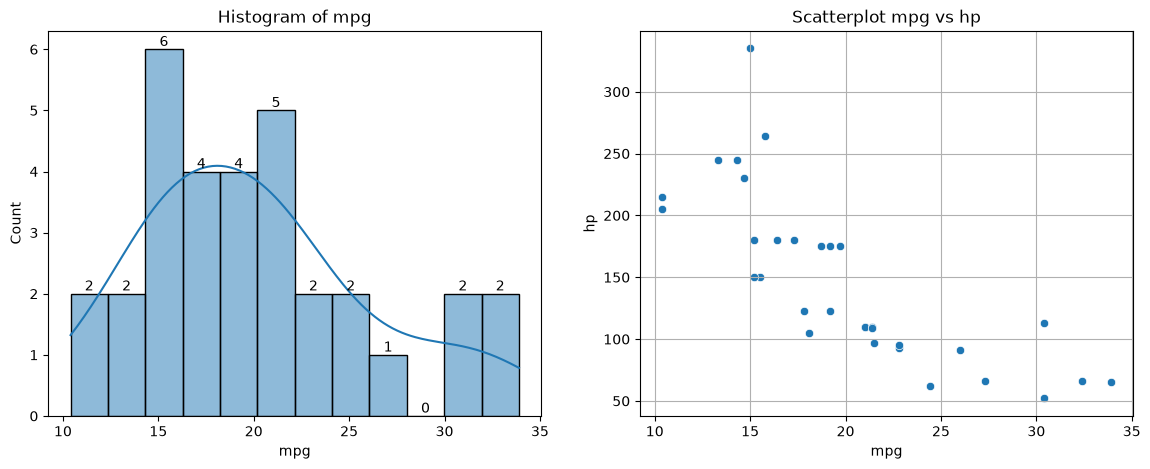

In [144]:
# 04. Visualize the Dataset

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 04-1. Create a histogram of the mpg variable: 
sns.histplot(data=df.mpg, kde=True, binwidth=2, ax=ax[0])
ax[0].set_xticks(np.arange(10, 36, 5))
ax[0].set_title("Histogram of mpg")

for container in ax[0].containers:
    ax[0].bar_label(container)

# 04-2. Create a scatterplot of mpg vs. hp (horsepower):
sns.scatterplot(data=df, x="mpg", y="hp", ax=ax[1])
ax[1].grid(True)
ax[1].set_title("Scatterplot mpg vs hp")



In [145]:
# 05. Group Data by Cylinders
# 05-1. Display groups
#display(df.sort_values("cyl"))

for(cyl, group) in df.groupby("cyl"):
    display(group)

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
17,Fiat 128,32.4,4,78.7,66,4.08,2.200,19.47,1,1,4,1
18,Honda Civic,30.4,4,75.7,52,4.93,1.615,18.52,1,1,4,2
19,Toyota Corolla,33.9,4,71.1,65,4.22,1.835,19.90,1,1,4,1
20,Toyota Corona,21.5,4,120.1,97,3.70,2.465,20.01,1,0,3,1
25,Fiat X1-9,27.3,4,79.0,66,4.08,1.935,18.90,1,1,4,1
26,Porsche 914-2,26.0,4,120.3,91,4.43,2.140,16.70,0,1,5,2
27,Lotus Europa,30.4,4,95.1,113,3.77,1.513,16.90,1,1,5,2


,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4
10,Merc 280C,17.8,6,167.6,123,3.92,3.440,18.90,1,0,4,4
29,Ferrari Dino,19.7,6,145.0,175,3.62,2.770,15.50,0,1,5,6


,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
11,Merc 450SE,16.4,8,275.8,180,3.07,4.070,17.40,0,0,3,3
12,Merc 450SL,17.3,8,275.8,180,3.07,3.730,17.60,0,0,3,3
13,Merc 450SLC,15.2,8,275.8,180,3.07,3.780,18.00,0,0,3,3
14,Cadillac Fleetwood,10.4,8,472.0,205,2.93,5.250,17.98,0,0,3,4
15,Lincoln Continental,10.4,8,460.0,215,3.00,5.424,17.82,0,0,3,4
16,Chrysler Imperial,14.7,8,440.0,230,3.23,5.345,17.42,0,0,3,4
21,Dodge Challenger,15.5,8,318.0,150,2.76,3.520,16.87,0,0,3,2
22,AMC Javelin,15.2,8,304.0,150,3.15,3.435,17.30,0,0,3,2


In [146]:
# 05-2. Calculate the average mpg for each cyl group (number of cylinders)

for(cyl, group) in df.groupby("cyl"):
    display(f"cyl: {cyl} - mean mpg: {group.mpg.mean()}")

'cyl: 4 - mean mpg: 26.66363636363636'

'cyl: 6 - mean mpg: 19.74285714285714'

'cyl: 8 - mean mpg: 15.1'

# Reflection
## 01. What trends do you notice between mpg and hp
From the scatterplot in **04-2**, there appears to be a negative correlation between the mpg and hp.  
cars with higher horsepower tend to have lower fuel efficiency (mpg), while cars with lower horsepower tend to have higher mpg.

## 02. How does mpg vary across different cyl groups?
From the mean calculations, the average mpg decreases as the number of the cylinders.  
The **4-cyl** group has the **highest** average mpg at *26.66*, followed by the **6-cyl** group with average mpg value at *19.74*, while the **8-cyl** has the **lowest** average mpg at *15.1*.  
This suggests that cars with more cylinders tend to have lower fuel efficiency.